In [10]:
import numpy as np
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVR
from sklearn.ensemble import GradientBoostingRegressor
from scipy.stats import spearmanr
import pandas as pd

 50 条真实 Cas12a 错配数据集

In [11]:
data = [
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "AGGTTCGCGTGGATTAAAGG",
        "mismatch_pos": 0,
        "relative_activity": 1.244067,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "GGGTTCGCGTGGATTAAAGG",
        "mismatch_pos": 0,
        "relative_activity": 1.536652,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "TGGTTCGCGTGGATTAAAGG",
        "mismatch_pos": 0,
        "relative_activity": 1.349063,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CAGTTCGCGTGGATTAAAGG",
        "mismatch_pos": 1,
        "relative_activity": 1.002632,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CCGTTCGCGTGGATTAAAGG",
        "mismatch_pos": 1,
        "relative_activity": 1.327277,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CTGTTCGCGTGGATTAAAGG",
        "mismatch_pos": 1,
        "relative_activity": 1.293087,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGATTCGCGTGGATTAAAGG",
        "mismatch_pos": 2,
        "relative_activity": 1.108303,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGCTTCGCGTGGATTAAAGG",
        "mismatch_pos": 2,
        "relative_activity": 1.294277,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGTTTCGCGTGGATTAAAGG",
        "mismatch_pos": 2,
        "relative_activity": 1.230956,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGATCGCGTGGATTAAAGG",
        "mismatch_pos": 3,
        "relative_activity": 1.275075,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGCTCGCGTGGATTAAAGG",
        "mismatch_pos": 3,
        "relative_activity": 1.259007,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGGTCGCGTGGATTAAAGG",
        "mismatch_pos": 3,
        "relative_activity": 1.422551,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTACGCGTGGATTAAAGG",
        "mismatch_pos": 4,
        "relative_activity": 1.206470,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTCCGCGTGGATTAAAGG",
        "mismatch_pos": 4,
        "relative_activity": 1.287469,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTGCGCGTGGATTAAAGG",
        "mismatch_pos": 4,
        "relative_activity": 1.460275,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTAGCGTGGATTAAAGG",
        "mismatch_pos": 5,
        "relative_activity": 1.150048,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTGGCGTGGATTAAAGG",
        "mismatch_pos": 5,
        "relative_activity": 1.344187,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTTGCGTGGATTAAAGG",
        "mismatch_pos": 5,
        "relative_activity": 1.151763,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTCACGTGGATTAAAGG",
        "mismatch_pos": 6,
        "relative_activity": 0.966740,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTCCCGTGGATTAAAGG",
        "mismatch_pos": 6,
        "relative_activity": 1.109856,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTCTCGTGGATTAAAGG",
        "mismatch_pos": 6,
        "relative_activity": 1.107226,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTCGAGTGGATTAAAGG",
        "mismatch_pos": 7,
        "relative_activity": 1.085175,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTCGGGTGGATTAAAGG",
        "mismatch_pos": 7,
        "relative_activity": 1.202152,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTCGTGTGGATTAAAGG",
        "mismatch_pos": 7,
        "relative_activity": 1.058207,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTCGCATGGATTAAAGG",
        "mismatch_pos": 8,
        "relative_activity": 1.037646,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTCGCCTGGATTAAAGG",
        "mismatch_pos": 8,
        "relative_activity": 1.133941,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTCGCTTGGATTAAAGG",
        "mismatch_pos": 8,
        "relative_activity": 1.131164,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTCGCGAGGATTAAAGG",
        "mismatch_pos": 9,
        "relative_activity": 1.108452,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTCGCGCGGATTAAAGG",
        "mismatch_pos": 9,
        "relative_activity": 1.241383,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTCGCGGGGATTAAAGG",
        "mismatch_pos": 9,
        "relative_activity": 1.171693,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTCGCGTAGATTAAAGG",
        "mismatch_pos": 10,
        "relative_activity": 1.054520,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTCGCGTCGATTAAAGG",
        "mismatch_pos": 10,
        "relative_activity": 1.267676,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTCGCGTTGATTAAAGG",
        "mismatch_pos": 10,
        "relative_activity": 1.222937,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTCGCGTGAATTAAAGG",
        "mismatch_pos": 11,
        "relative_activity": 0.994914,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTCGCGTGCATTAAAGG",
        "mismatch_pos": 11,
        "relative_activity": 1.275432,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTCGCGTGTATTAAAGG",
        "mismatch_pos": 11,
        "relative_activity": 1.181162,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTCGCGTGGCTTAAAGG",
        "mismatch_pos": 12,
        "relative_activity": 1.315327,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTCGCGTGGGTTAAAGG",
        "mismatch_pos": 12,
        "relative_activity": 1.241909,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTCGCGTGGTTTAAAGG",
        "mismatch_pos": 12,
        "relative_activity": 1.321736,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTCGCGTGGAATAAAGG",
        "mismatch_pos": 13,
        "relative_activity": 1.173173,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTCGCGTGGACTAAAGG",
        "mismatch_pos": 13,
        "relative_activity": 1.114124,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTCGCGTGGAGTAAAGG",
        "mismatch_pos": 13,
        "relative_activity": 1.276508,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTCGCGTGGATAAAAGG",
        "mismatch_pos": 14,
        "relative_activity": 1.171015,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTCGCGTGGATCAAAGG",
        "mismatch_pos": 14,
        "relative_activity": 1.209477,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTCGCGTGGATGAAAGG",
        "mismatch_pos": 14,
        "relative_activity": 1.376292,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTCGCGTGGATTCAAGG",
        "mismatch_pos": 15,
        "relative_activity": 1.349096,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTCGCGTGGATTGAAGG",
        "mismatch_pos": 15,
        "relative_activity": 1.274115,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTCGCGTGGATTTAAGG",
        "mismatch_pos": 15,
        "relative_activity": 1.199478,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTCGCGTGGATTACAGG",
        "mismatch_pos": 16,
        "relative_activity": 1.355353,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTCGCGTGGATTAGAGG",
        "mismatch_pos": 16,
        "relative_activity": 1.332736,
    },
]

df = pd.DataFrame(data)

最终特征提取

In [19]:
import numpy as np
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVR
from sklearn.ensemble import GradientBoostingRegressor
from scipy.stats import spearmanr
import pandas as pd
# ===== 重新提取特征 =====
X_final = np.array([
    extract_final_features(row["spacer_seq"], row["target_seq"], row["mismatch_pos"])
    for _, row in df.iterrows()
])
y = df["relative_activity"].values

In [20]:
def extract_final_features_v3(spacer, target, mismatch_pos):
    import RNA

    duplex = RNA.duplexfold(spacer, target)
    dg_duplex = duplex.energy
    dg_perfect = RNA.duplexfold(spacer, spacer.replace("U", "T")).energy
    ddg = dg_duplex - dg_perfect

    pos = int(mismatch_pos)
    sp_base = spacer[pos] if pos < len(spacer) else "N"
    tg_base = target[pos] if pos < len(target) else "N"

    is_purine_mismatch = 1 if (sp_base in ["A", "G"] and tg_base in ["A", "G"]) else 0
    transitions = [("A", "G"), ("G", "A"), ("C", "T"), ("T", "C")]
    is_transition = 1 if (sp_base, tg_base) in transitions else 0
    is_edge = 1 if (pos <= 2 or pos >= 17) else 0
    pos_ddg_interaction = pos * ddg

    # 新增：错配严重程度评分（基于 Cas12a 文献）
    mismatch_severity = {
        ("A", "C"): 3, ("C", "A"): 3,
        ("G", "A"): 2, ("A", "G"): 2,
        ("C", "T"): 1, ("T", "C"): 1,
        ("G", "T"): 0, ("T", "G"): 0,
        ("U", "G"): 0, ("G", "U"): 0,
    }
    mismatch_score = mismatch_severity.get((sp_base, tg_base), 2)

    # 新增：seed region 加权（前8位对活性影响更大）
    seed_weight = 1.5 if pos <= 8 else 1.0

    return [pos, ddg, is_purine_mismatch, is_transition,
            is_edge, pos_ddg_interaction, mismatch_score, seed_weight]


# 重新提取特征并训练

X_v3 = np.array([
    extract_final_features_v3(row["spacer_seq"], row["target_seq"], row["mismatch_pos"])
    for _, row in df.iterrows()
])

# 用新调优的 SVR 参数
svr_v3 = make_pipeline(StandardScaler(), SVR(kernel="rbf", C=20, epsilon=0.05, gamma=0.05))
gb_v3 = GradientBoostingRegressor(n_estimators=100, max_depth=2,
                                   learning_rate=0.05, subsample=0.8, random_state=42)

y_pred_svr_v3 = cross_val_predict(svr_v3, X_v3, y, cv=LeaveOneOut())
y_pred_gb_v3 = cross_val_predict(gb_v3, X_v3, y, cv=LeaveOneOut())
y_pred_v3 = (y_pred_svr_v3 + y_pred_gb_v3) / 2

rho_v3, p_v3 = spearmanr(y, y_pred_v3)
print(f"v3 (8特征 + 新SVR参数): r_s = {rho_v3:.3f}, p = {p_v3:.4e}")

v3 (8特征 + 新SVR参数): r_s = 0.721, p = 3.6449e-09


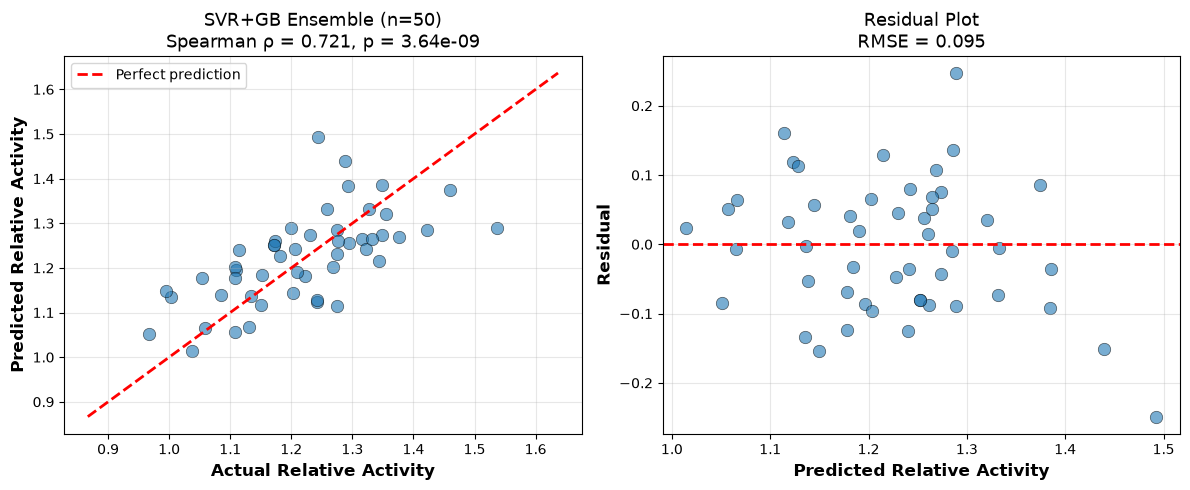

In [21]:
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from sklearn.metrics import mean_squared_error
import numpy as np
rho, p = spearmanr(y, y_pred_v3)
rmse = np.sqrt(mean_squared_error(y, y_pred_v3))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax1 = axes[0]
ax1.scatter(y, y_pred_v3, alpha=0.6, s=80, edgecolors='black', linewidth=0.5)
lim = [min(y.min(), y_pred_v3.min()) - 0.1, max(y.max(), y_pred_v3.max()) + 0.1]
ax1.plot(lim, lim, 'r--', linewidth=2, label='Perfect prediction')
ax1.set_xlabel('Actual Relative Activity', fontsize=12, fontweight='bold')
ax1.set_ylabel('Predicted Relative Activity', fontsize=12, fontweight='bold')
ax1.set_title(f'SVR+GB Ensemble (n=50)\nSpearman ρ = {rho:.3f}, p = {p:.2e}', fontsize=13)
ax1.legend()
ax1.grid(alpha=0.3)

ax2 = axes[1]
residuals_v3 = y - y_pred_v3
ax2.scatter(y_pred_v3, residuals_v3, alpha=0.6, s=80, edgecolors='black', linewidth=0.5)
ax2.axhline(0, color='red', linestyle='--', linewidth=2)
ax2.set_xlabel('Predicted Relative Activity', fontsize=12, fontweight='bold')
ax2.set_ylabel('Residual', fontsize=12, fontweight='bold')
ax2.set_title(f'Residual Plot\nRMSE = {rmse:.3f}', fontsize=13)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('model_v3_performance.png', dpi=300, bbox_inches='tight')
plt.show()

In [23]:
import numpy as np
import pandas as pd

candidates = pd.read_csv("candidate_sequences.csv")

# 重命名列以匹配你的特征提取函数
candidates.rename(columns={
    "crRNA_sequence_5to3": "spacer_seq",
    "mature_mirna_sequence_rna": "target_seq"
}, inplace=True)

# 如果你的 extract_final_features_v3 需要 mismatch_pos，但 CSV 里没有这列
# 需要先生成它，假设是完美匹配的情况：
if "mismatch_pos" not in candidates.columns:
    candidates["mismatch_pos"] = -1  # 或者根据实际情况计算错配位置

# 预测对 miR-29a 的活性
X_candidates = np.array([
    extract_final_features_v3(
        row["spacer_seq"], row["target_seq"], row["mismatch_pos"]
    )
    for _, row in candidates.iterrows()
])

# 用训练好的模型预测
svr_v3.fit(X_v3, y)
gb_v3.fit(X_v3, y)

pred_activity = (svr_v3.predict(X_candidates) + gb_v3.predict(X_candidates)) / 2
candidates["predicted_activity"] = pred_activity
candidates.sort_values("predicted_activity", ascending=False).to_csv("ranked_crRNA.csv", index=False)
print(candidates.head(10))

  candidate_id target_mirna            spacer_seq  spacer_length_nt  \
0    CRRNA-001   miR-29a-3p  UAGCACCAUCUGAAAUCGGU                20   
1    CRRNA-002   miR-29a-3p  AGCACCAUCUGAAAUCGGUU                20   
2    CRRNA-003   miR-29b-3p  UAGCACCAUUUGAAAUCAGU                20   
3    CRRNA-004   miR-29c-3p  UAGCACCAUUUGAAAUCGGU                20   
4    CRRNA-005   miR-29c-3p  AGCACCAUUUGAAAUCGGUU                20   

   window_start_nt  window_end_nt             target_seq  \
0                1             20  UAGCACCAUCUGAAAUCGGUU   
1                2             21  UAGCACCAUCUGAAAUCGGUU   
2                1             20   UAGCACCAUUUGAAAUCAGU   
3                1             20  UAGCACCAUUUGAAAUCGGUU   
4                2             21  UAGCACCAUUUGAAAUCGGUU   

  mature_mirna_sequence_dna                              design_status  \
0     TAGCACCATCTGAAATCGGTT  Cas12a spacer candidate; PAM not verified   
1     TAGCACCATCTGAAATCGGTT  Cas12a spacer candidate; PAM not ve